# Notebook 03: Features Estructurales — HITO 3

**TFM de Bioinformática Estructural — Familia RAS**  
**Objetivos del hito:** calcular SASA, distancia al sitio activo y conservación evolutiva para los 166 residuos del dominio G de KRAS, HRAS y NRAS; integrar todo en la tabla maestra `master_features.csv`.

---

## Contexto biológico

### ¿Qué es la SASA?

La **SASA** (*Solvent Accessible Surface Area*, área superficial accesible al solvente) es la fracción de la superficie de un residuo aminoacídico que puede estar en contacto con moléculas de agua del entorno. Se calcula haciendo rodar una esfera-sonda de radio 1.4 Å (radio del agua) sobre la superficie de Van der Waals de la proteína.

- **SASA absoluta** (sasa_abs): área en Å² accesible al solvente para ese residuo en la estructura cristalizada.
- **SASA relativa** (sasa_rel): cociente entre la SASA absoluta y la SASA máxima posible para ese aminoácido (calculada en un tripéptido de referencia extendido Gly-X-Gly). Un valor de 0 significa residuo totalmente enterrado; valores próximos a 1 (o incluso >1 por aproximaciones) significan residuo completamente expuesto.

**Relevancia funcional:** los residuos del sitio activo suelen estar *enterrados* (SASA_rel < 0.25) porque la cavidad de unión del GTP queda en el interior de la proteína. Un residuo enterrado que muta puede alterar el *packing* hidrofóbico o crear impedimentos estéricos sin cambiar la exposición superficial, lo que explica por qué muchos oncogenes mutan en posiciones con SASA baja.

Existen dos métodos principales:
- **DSSP** (*Dictionary of Secondary Structure of Proteins*): usa el algoritmo de Lee & Richards para calcular SASA a la vez que asigna estructura secundaria. Es el método estándar en cristalografía.
- **Shrake-Rupley**: coloca puntos uniformemente distribuidos sobre la esfera de cada átomo y cuenta los que no son ocluidos por átomos vecinos. Es más rápido y no requiere el ejecutable DSSP.

En este notebook se usa la implementación de BioPython que delega en DSSP si está disponible, y usa Shrake-Rupley como alternativa robusta.

### ¿Qué es el sitio activo de RAS?

Las proteínas RAS son **GTPasas pequeñas**: catalizan la hidrólisis de GTP a GDP liberando fosfato inorgánico. El cambio GTP→GDP actúa como interruptor molecular: RAS-GTP está activo y promueve proliferación celular; RAS-GDP está inactivo.

El **sitio activo** comprende los átomos del nucleótido (GDP o GTP) y del ion Mg²⁺ coordinador. Las regiones proteicas que definen el sitio activo son:

| Región | Residuos KRAS | Función |
|--------|---------------|---------|
| P-loop (G1) | 10-17 | Une el fosfato del nucleótido |
| Switch I (G2) | 30-38 | Cambia conformación al hidrolizar GTP |
| Switch II (G3) | 60-76 | Q61 catalítico; interacción con GAP |
| NKxD (G4) | 116-119 | Reconocimiento de la base guanina |
| SAK (G5) | 145-147 | Segunda región de especificidad de guanina |

G12 (Gly en posición 12 del P-loop) está en contacto directo con el fosfato γ del GTP. Una mutación G12D/V/C impide la interacción con la proteína GAP (*GTPase-Activating Protein*) que normalmente acelera la hidrólisis del GTP, dejando a RAS constitutivamente activo.

### ¿Por qué calculamos la distancia al sitio activo?

La **distancia mínima de átomos pesados** (átomos no-hidrógeno) entre un residuo y los átomos del ligando nos da una medida objetiva de la proximidad espacial al sitio de catálisis. Usamos la distancia mínima (en lugar de la distancia entre centros de masa) porque:
1. Mejor refleja el contacto potencial real entre residuo y ligando.
2. Es sensible a la orientación de la cadena lateral (que puede extenderse hacia el ligando).
3. Es la definición usada en estudios de redes de contacto proteína-ligando.

**Criterio biológico:** residuos a < 5 Å del sitio activo forman parte de la primera esfera de coordinación y su mutación impacta directamente en la catálisis o en la afinidad por el nucleótido.

### ¿Qué es la entropía de Shannon en un MSA?

La **entropía de Shannon** mide la variabilidad de una columna del alineamiento múltiple (MSA). Para una columna con frecuencias de aminoácidos $p_1, p_2, ..., p_k$:

$$H = -\sum_{i} p_i \log_2(p_i)$$

- H = 0: la columna es completamente conservada (todos los organismos/isoformas tienen el mismo aminoácido).
- H = log₂(20) ≈ 4.32 bits: máxima entropía (todos los aminoácidos son igualmente frecuentes).

Los hotspots oncogénicos como G12 tienen entropía cercana a cero porque la Glicina es funcionalmente irremplazable en esa posición: cualquier otro aminoácido introduce una cadena lateral que choca estéricamente con el fosfato γ del GTP.

---

## Estructura del notebook

1. Carga de configuración y datos del Hito 2
2. Cálculo de SASA por residuo (3 genes × 3 PDBs)
3. Cálculo de distancia al sitio activo
4. Cálculo de entropía de Shannon desde el MSA
5. Guardado de tablas intermedias
6. Verificaciones biológicas
7. Construcción de la tabla maestra
8. Guardado y visualización
9. Resumen estadístico

## Inputs esperados

- `data/processed/cosmic_curated.csv`
- `data/processed/position_map.csv`
- `data/processed/recurrent_positions.csv`
- PDBs en `data/external/pdb/` o descargables desde RCSB

## 1. Configuración y carga de datos

In [1]:
# ============================================================
# CHUNK 1.1: Importaciones y configuración general
# ============================================================

# Importaciones de la biblioteca estándar de Python
import math          # Módulo matemático: usaremos math.log2 para la entropía de Shannon
import sys           # Acceso a información del intérprete Python (versión, rutas)
import warnings      # Control de mensajes de advertencia durante la ejecución
from pathlib import Path  # Clase orientada a objetos para rutas del sistema de ficheros

# Importaciones de bibliotecas científicas externas
import numpy as np   # Operaciones numéricas sobre arrays; np.linalg.norm calcula distancias euclídeas
import pandas as pd  # Manipulación de tablas de datos (DataFrames); pd.concat combina tablas

# BioPython: biblioteca bioinformática de referencia
# AlignIO: lectura y escritura de ficheros de alineamiento múltiple en distintos formatos
from Bio import AlignIO

# Importaciones del paquete propio del TFM
# load_config: carga el fichero configs/config.yaml como diccionario Python
# project_root: devuelve la ruta absoluta al directorio raíz del proyecto
from tfm_ras.config import load_config, project_root

# Importaciones del módulo structural.py (implementa los cálculos del Hito 3)
# fetch_pdb: descarga un PDB desde RCSB si no existe localmente
# parse_structure: lee un fichero .pdb y devuelve un objeto Structure de BioPython
# get_active_site_atoms: extrae los átomos del sitio activo (ligando + Mg2+)
# compute_sasa: calcula SASA absoluta y relativa por residuo
# distance_to_active_site: calcula distancia mínima de átomos pesados al sitio activo
# shannon_entropy_per_position: calcula entropía de Shannon por columna del MSA
# merge_features: combina todas las métricas en la tabla maestra
# plot_features_overview: genera la figura resumen de features (firma: plot_features_overview(master, output_path))
# MASTER_COLUMNS: lista que define el esquema de columnas de la tabla maestra
from tfm_ras.structural import (
    MASTER_COLUMNS,
    compute_sasa,
    distance_to_active_site,
    fetch_pdb,
    get_active_site_atoms,
    merge_features,
    parse_structure,
    plot_features_overview,
    shannon_entropy_per_position,
)

# Supprimimos los warnings de BioPython sobre átomos con ocupancia alternativa
# (muy comunes en estructuras de alta resolución como 3K8Y a 1.31 Å).
# 'ignore' hace que no aparezcan en la salida del notebook; solo suprimimos
# los de tipo UserWarning para no silenciar advertencias de otros módulos.
warnings.filterwarnings("ignore", category=UserWarning, module="Bio")

# Verificamos la versión de Python instalada
print(f"Python {sys.version}")
print("Importaciones completadas correctamente.")

Python 3.11.15 | packaged by conda-forge | (main, Mar  5 2026, 16:58:53) [Clang 19.1.7 ]
Importaciones completadas correctamente.


In [2]:
# ============================================================
# CHUNK 1.2: Carga de la configuración del proyecto
# ============================================================

# project_root() devuelve la ruta absoluta al directorio raíz del proyecto,
# calculada dinámicamente a partir de la posición del fichero config.py.
# Esto hace que el notebook funcione independientemente del directorio de trabajo
# actual del sistema operativo.
ROOT = project_root()
print(f"Raíz del proyecto: {ROOT}")

# load_config() lee configs/config.yaml y lo convierte en un diccionario Python.
# Esta configuración centraliza todas las rutas, parámetros y constantes biológicas
# del proyecto, evitando valores hardcodeados dispersos por el código.
CFG = load_config(ROOT / 'configs' / 'config.yaml')

# Definimos las rutas a los directorios de datos como objetos Path.
# El operador '/' de pathlib construye rutas de forma portable (compatible con
# Linux, macOS y Windows), equivalente a os.path.join pero más legible.
PROCESSED_DIR = ROOT / "data" / "processed"   # directorio de resultados intermedios
PDB_DIR = ROOT / "data" / "external" / "pdb"  # directorio de estructuras PDB locales
FIGURES_DIR = ROOT / "figures"                 # directorio de figuras del TFM

# Creamos los directorios si no existen (exist_ok=True evita error si ya existen).
# parents=True crea también los directorios intermedios que falten.
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)  # asegurar que el directorio existe
FIGURES_DIR.mkdir(parents=True, exist_ok=True)     # ídem para figuras

# Extraemos los parámetros de configuración relevantes para este notebook.
# CFG["family"]["members"] es un diccionario anidado con info de cada gen RAS.
members_cfg = CFG["family"]["members"]  # {"KRAS": {...}, "HRAS": {...}, "NRAS": {...}}

# Construimos el mapa gen → PDB_ID usando el PDB primario de cada gen.
# Este mapa es la fuente de verdad para saber qué estructura usar en cada análisis.
# KRAS → 4OBE (GDP-bound, resolución 1.24 Å)
# HRAS → 3K8Y (GppNHp-bound, resolución 1.30 Å)
# NRAS → 5UHV (GppNHp-bound, resolución 1.67 Å)
PDB_BY_GENE = {
    gene: members_cfg[gene]["pdbs"]["primary"]["id"]  # extrae el ID del PDB primario
    for gene in ("KRAS", "HRAS", "NRAS")              # para cada uno de los tres genes
}

print("\nMapa gen → PDB primario:")
for gene, pdb_id in PDB_BY_GENE.items():  # iteramos sobre el diccionario para mostrar
    ligand = members_cfg[gene]["pdbs"]["primary"].get("ligand", "N/A")  # ligando unido
    res = members_cfg[gene]["pdbs"]["primary"].get("resolution_angstrom", "N/A")  # resolución
    print(f"  {gene}: {pdb_id}  (ligando: {ligand}, resolución: {res} Å)")

# Extraemos los hotspots oncogénicos desde la configuración.
# CFG["hotspots"] es una lista de diccionarios: [{"position": 12, "residue": "G"}, ...]
hotspots = CFG["hotspots"]  # posiciones conocidas como drivers oncogénicos
hotspot_positions = [h["position"] for h in hotspots]  # extraemos solo los números
print(f"\nHotspots oncogénicos a verificar: {hotspot_positions}")

Raíz del proyecto: /Users/rachi/Desktop/TFM/tfm_ras_mutations

Mapa gen → PDB primario:
  KRAS: 4OBE  (ligando: GDP, resolución: 1.24 Å)
  HRAS: 3K8Y  (ligando: GppNHp, resolución: 1.3 Å)
  NRAS: 5UHV  (ligando: GppNHp, resolución: 1.67 Å)

Hotspots oncogénicos a verificar: [12, 13, 61]


In [3]:
# ============================================================
# CHUNK 1.3: Carga de datos generados en los hitos anteriores
# ============================================================

# --- Datos del Hito 1: mutaciones COSMIC curadas ---
# cosmic_curated.csv contiene las mutaciones somáticas missense de KRAS, HRAS y NRAS
# filtradas, deduplicadas y estructuradas por el notebook 01.
# Columnas relevantes: gene, position, wt_aa, mut_aa, hgvs_p, sample_count
cosmic_curated_path = PROCESSED_DIR / "cosmic_curated.csv"  # ruta al fichero
mutations = pd.read_csv(cosmic_curated_path)  # pd.read_csv lee CSV y devuelve DataFrame
print(f"Mutaciones cargadas: {len(mutations)} filas")
print(f"  Columnas: {list(mutations.columns)}")
# .value_counts() cuenta cuántas filas hay por gen, devolviendo una Serie ordenada
print(f"  Mutaciones por gen:\n{mutations['gene'].value_counts().to_string()}")

# --- Datos del Hito 2: mapa de posiciones del MSA ---
# position_map.csv traduce entre posiciones en KRAS, HRAS, NRAS y posición en el MSA.
# Columnas: msa_position, kras_position, hras_position, nras_position,
#           kras_aa, hras_aa, nras_aa, conserved
position_map_path = PROCESSED_DIR / "position_map.csv"  # ruta al fichero
position_map = pd.read_csv(position_map_path)  # leemos el CSV del mapa posicional
print(f"\nMapa de posiciones cargado: {len(position_map)} columnas del MSA")
print(f"  Columnas: {list(position_map.columns)}")

# --- Datos del Hito 2: MSA en formato FASTA ---
# msa_ras.fasta contiene el alineamiento múltiple de las tres isoformas RAS.
# Se usa para calcular la entropía de Shannon por posición.
msa_path = PROCESSED_DIR / "msa_ras.fasta"  # ruta al fichero FASTA del alineamiento

# AlignIO.read(ruta, formato) lee un fichero de alineamiento y devuelve un objeto
# MultipleSeqAlignment de BioPython que contiene todos los registros del MSA.
# El formato 'fasta' indica que el fichero sigue la convención de cabeceras '>id'.
msa = AlignIO.read(str(msa_path), "fasta")  # str() convierte Path a cadena por compatibilidad
print(f"\nMSA cargado:")
print(f"  Número de secuencias: {len(msa)}")
print(f"  Longitud del alineamiento: {msa.get_alignment_length()} columnas")
for record in msa:  # iteramos sobre cada secuencia del alineamiento para mostrar su ID
    print(f"  - {record.id}: {len(str(record.seq).replace('-', ''))} residuos (sin gaps)")

# --- Datos del Hito 2: posiciones recurrentes (opcional, para contexto) ---
recurrent_path = PROCESSED_DIR / "recurrent_positions.csv"  # ruta al fichero
if recurrent_path.exists():  # comprobamos si el fichero existe antes de cargarlo
    recurrent = pd.read_csv(recurrent_path)  # cargamos si existe
    print(f"\nPosiciones recurrentes cargadas: {len(recurrent)} posiciones")
else:
    recurrent = None  # None es el valor centinela Python para "dato no disponible"
    print("\nFichero recurrent_positions.csv no encontrado (no es obligatorio para este hito).")

Mutaciones cargadas: 469 filas
  Columnas: ['gene', 'uniprot_id', 'position', 'wt_aa', 'mut_aa', 'hgvs_p', 'sample_count', 'tumor_types', 'primary_tissues', 'cosmic_version']
  Mutaciones por gen:
gene
KRAS    207
NRAS    133
HRAS    129

Mapa de posiciones cargado: 189 columnas del MSA
  Columnas: ['msa_position', 'kras_position', 'hras_position', 'nras_position', 'kras_aa', 'hras_aa', 'nras_aa', 'conserved']

MSA cargado:
  Número de secuencias: 3
  Longitud del alineamiento: 189 columnas
  - KRAS: 189 residuos (sin gaps)
  - HRAS: 189 residuos (sin gaps)
  - NRAS: 189 residuos (sin gaps)

Posiciones recurrentes cargadas: 6 posiciones


## 2. Parseo de estructuras PDB

### ¿Qué es un fichero PDB y la jerarquía SMCRA?

Un fichero PDB (*Protein Data Bank*) contiene las coordenadas atómicas de una proteína obtenidas por cristalografía de rayos X, crioEM u otras técnicas. BioPython organiza esta información en una jerarquía de 5 niveles llamada **SMCRA**:

```
Structure (S)  → todo el fichero PDB
  Model (M)    → habitualmente 1 modelo en cristalografía; varios en NMR
    Chain (C)  → cadena polipeptídica (A, B, C...); la mayoría de RAS tiene cadena A
      Residue (R) → aminoácido o heteroátomo (ligando, agua, ion)
        Atom (A)  → átomo individual con coordenadas x, y, z
```

Los **heteroátomos** (HETATM en el PDB) incluyen:
- El nucleótido GDP/GTP o su análogo GppNHp (ligando que marca el sitio activo)
- El ion Mg²⁺ coordinador (esencial para la catálisis)
- Moléculas de agua cristalográfica

La función `parse_structure()` de nuestro módulo usa BioPython para leer el fichero PDB y devuelve el objeto `Structure` listo para ser analizado.

In [4]:
# ============================================================
# CHUNK 2.1: Parseo de los tres ficheros PDB
# ============================================================

# Diccionario donde almacenaremos los objetos Model de BioPython,
# uno por gen. Se inicializa vacío y se rellena en el bucle siguiente.
# NOTA: parse_structure() devuelve directamente el primer Model de la jerarquía
# SMCRA (Structure→Model→Chain→Residue→Atom), no el objeto Structure raíz.
structures = {}  # {"KRAS": <Model>, "HRAS": <Model>, "NRAS": <Model>}
structures_full = {}  # {"KRAS": <Model>, "HRAS": <Model>, "NRAS": <Model>}

print("Parseando estructuras PDB...")
print("-" * 50)

# Iteramos sobre los tres pares (gen, PDB_ID) definidos en el mapa PDB_BY_GENE.
# .items() devuelve pares (clave, valor) del diccionario en orden de inserción.
for gene, pdb_id in PDB_BY_GENE.items():
    # Construimos la ruta completa al fichero PDB local.
    # Si el fichero no existe, fetch_pdb() lo descargará automáticamente desde RCSB.
    pdb_path = PDB_DIR / f"{pdb_id}.pdb"  # f-string: inserta pdb_id en el nombre

    # Si el fichero PDB no existe localmente, lo descargamos desde RCSB PDB.
    # Esto garantiza que el notebook funciona incluso si los PDBs no están cacheados.
    if not pdb_path.exists():  # .exists() devuelve True si el fichero está en disco
        print(f"  {pdb_id}: descargando desde RCSB PDB...")
        # fetch_pdb() descarga el fichero, lo guarda en PDB_DIR y devuelve la ruta
        pdb_path = fetch_pdb(pdb_id, PDB_DIR)  # ruta local tras la descarga

    # parse_structure() lee el fichero PDB y devuelve el primer Model de BioPython.
    # Un Model (nivel 2 de SMCRA) contiene todas las cadenas (Chain) del cristal.
    # En estructuras de rayos X hay un único modelo; en RMN puede haber varios.

    structure_full = parse_structure(pdb_path)  # primer Model de la jerarquía SMCRA
    structures_full[gene] = structure_full 

    # Creamos una copia con sola la cadena A para los análisis posteriores.
    structure = parse_structure(pdb_path)
    chains_to_remove = [c.id for c in structure.get_chains() if c.id != 'A']
    for chain_id in chains_to_remove:
        structure.detach_child(chain_id)

    # Guardamos el modelo en el diccionario, indexado por nombre de gen.
    structures[gene] = structure  # clave: "KRAS", "HRAS" o "NRAS"

    # Inspeccionamos el modelo para verificar que se ha cargado correctamente.
    # Como parse_structure() devuelve el Model (no el Structure raíz),
    # accedemos directamente a sus cadenas sin el índice [0].
    chains = list(structure.get_chains())  # lista de objetos Chain del modelo
    chain_ids = [c.id for c in chains]     # lista de letras identificadoras de cadena

    # Contamos los residuos aminoacídicos de la cadena principal (cadena 'A').
    # residue.id[0] == ' ' distingue aminoácidos de heteroátomos (HETATM)
    # y residuos de agua ('W'); el espacio indica residuo polipeptídico estándar.
    main_chain = structure['A']  # acceso por ID de cadena: la cadena A del modelo
    amino_residues = [r for r in main_chain if r.id[0] == ' ']  # solo aminoácidos
    hetatm_residues = [r for r in structure.get_residues() 
                       if r.id[0].startswith('H_')]  # heteroátomos

    print(f"  {gene} ({pdb_id}):")
    print(f"    Cadenas: {chain_ids}")
    print(f"    Residuos aminoacídicos (cadena A): {len(amino_residues)}")
    print(f"    Heteroátomos (ligandos, iones) (cadena A): {len(hetatm_residues)}")
    for r in hetatm_residues:
        print(f"      - {r.resname} ID: {r.id}")

print("-" * 50)
print(f"Total estructuras cargadas: {len(structures)}")


Parseando estructuras PDB...
--------------------------------------------------
  KRAS (4OBE):
    Cadenas: ['A']
    Residuos aminoacídicos (cadena A): 169
    Heteroátomos (ligandos, iones) (cadena A): 2
      - GDP ID: ('H_GDP', 201, ' ')
      - MG ID: ('H_MG', 202, ' ')
  HRAS (3K8Y):
    Cadenas: ['A']
    Residuos aminoacídicos (cadena A): 166
    Heteroátomos (ligandos, iones) (cadena A): 6
      - GNP ID: ('H_GNP', 528, ' ')
      - CA ID: ('H_CA', 167, ' ')
      - MG ID: ('H_MG', 168, ' ')
      - CA ID: ('H_CA', 169, ' ')
      - MG ID: ('H_MG', 170, ' ')
      - ACT ID: ('H_ACT', 719, ' ')
  NRAS (5UHV):
    Cadenas: ['A']
    Residuos aminoacídicos (cadena A): 166
    Heteroátomos (ligandos, iones) (cadena A): 3
      - GNP ID: ('H_GNP', 201, ' ')
      - MG ID: ('H_MG', 202, ' ')
      - GOL ID: ('H_GOL', 203, ' ')
--------------------------------------------------
Total estructuras cargadas: 3


## 3. Extracción del sitio activo

### ¿Qué átomos forman el sitio activo de RAS?

La función `get_active_site_atoms()` extrae los átomos de:
1. **El nucleótido unido** (GDP en 4OBE; GppNHp en 3K8Y y 5UHV): átomo con nombre de residuo GDP/GTP/GNP/GCP o similar.
2. **El ion Mg²⁺** (MG en la nomenclatura PDB): cofactor metálico que coordina los fosfatos del nucleótido y es indispensable para la catálisis.

Estos átomos definen la geometría del sitio activo y son la referencia para calcular distancias de todos los residuos proteicos.

In [5]:
# ============================================================
# CHUNK 3.1: Extracción de átomos del sitio activo
# ============================================================

# Diccionario donde almacenaremos los átomos del sitio activo para cada gen.
# Cada valor es una lista de objetos Atom de BioPython con coordenadas x, y, z.
active_site_atoms_by_gene = {}  # {"KRAS": [Atom, ...], "HRAS": [...], "NRAS": [...]}

print("Extrayendo átomos del sitio activo...")
print("-" * 50)

for gene, structure in structures.items():  # iteramos sobre el diccionario de estructuras
    # get_active_site_atoms() busca en la estructura los heteroátomos que forman
    # el sitio activo: el nucleótido (GDP/GTP/GppNHp) y el ion Mg2+.
    # Devuelve una lista de objetos Atom de BioPython.
    active_atoms = get_active_site_atoms(structure)  # lista de átomos del sitio activo

    # Guardamos la lista en el diccionario indexado por gen.
    active_site_atoms_by_gene[gene] = active_atoms

    # Obtenemos los nombres únicos de los residuos a los que pertenecen los átomos,
    # para verificar que se han extraído el ligando correcto y el ion Mg2+.
    # atom.get_parent() devuelve el objeto Residue al que pertenece cada átomo.
    # .resname es el nombre del residuo (3 letras): GDP, GNP, MG, HOH, etc.
    residue_names = set(a.get_parent().resname for a in active_atoms)  # nombres únicos

    pdb_id = PDB_BY_GENE[gene]  # obtenemos el ID del PDB correspondiente al gen
    print(f"  {gene} ({pdb_id}):")
    print(f"    Átomos del sitio activo: {len(active_atoms)}")
    print(f"    Nombres de residuos (HETATM): {sorted(residue_names)}")

    # Verificamos que se ha encontrado al menos 1 átomo del sitio activo.
    # Si la lista está vacía, algo ha ido mal con la extracción o el PDB no tiene ligando.
    assert len(active_atoms) > 0, (
        f"ERROR: no se encontraron átomos del sitio activo en {gene} ({pdb_id}). "
        f"Verifica que el PDB contiene GDP/GTP/GppNHp y MG."
    )

print("-" * 50)
print("Sitios activos extraídos correctamente.")

Extrayendo átomos del sitio activo...
--------------------------------------------------
  KRAS (4OBE):
    Átomos del sitio activo: 38
    Nombres de residuos (HETATM): ['GDP', 'MG']
  HRAS (3K8Y):
    Átomos del sitio activo: 33
    Nombres de residuos (HETATM): ['GNP', 'MG']
  NRAS (5UHV):
    Átomos del sitio activo: 33
    Nombres de residuos (HETATM): ['GNP', 'MG']
--------------------------------------------------
Sitios activos extraídos correctamente.


## 4. Cálculo de SASA por residuo

Para cada gen calculamos la SASA absoluta (Å²) y relativa (adimensional) de todos los residuos del dominio G (posiciones 1-166). El DataFrame resultante tiene columnas `position`, `residue`, `sasa_abs`, `sasa_rel`.

In [6]:
# ============================================================
# CHUNK 4.1: Cálculo de SASA para los tres genes
# ============================================================

# Lista donde acumularemos los DataFrames de SASA de los tres genes.
# Al final los combinaremos con pd.concat() en un único DataFrame.
sasa_frames = []  # lista vacía que se llenará en el bucle

print("Calculando SASA por residuo...")
print("-" * 50)

for gene, structure in structures.items():  # iteramos sobre los tres genes
    # compute_sasa() aplica el algoritmo de Shrake-Rupley (o DSSP si está disponible)
    # a la estructura y devuelve un DataFrame con las columnas:
    #   position  : número de residuo en la secuencia (1-based, numeración UniProt)
    #   residue   : código de 3 letras del aminoácido (e.g. "GLY", "GLN")
    #   sasa_abs  : área accesible al solvente en Angstroms cuadrados
    #   sasa_rel  : SASA normalizada por la SASA máxima del aminoácido (0-1)
    sasa_df = compute_sasa(structure)  # DataFrame con SASA por residuo

    # Añadimos una columna 'gene' para identificar a qué proteína corresponde cada fila.
    # Esto es necesario porque luego combinaremos las tablas de los 3 genes con pd.concat().
    # La asignación vectorizada df["col"] = valor establece el mismo valor en todas las filas.
    sasa_df["gene"] = gene  # añadimos el nombre del gen en cada fila

    # Añadimos el DataFrame a la lista de frames para la concatenación final.
    sasa_frames.append(sasa_df)  # acumulamos el DataFrame del gen actual

    # Mostramos estadísticas descriptivas básicas para inspección visual.
    # .describe() calcula count, mean, std, min, percentiles y max de columnas numéricas.
    print(f"\n  {gene}: {len(sasa_df)} residuos calculados")
    print(f"    SASA relativa — media: {sasa_df['sasa_rel'].mean():.3f}, "
          f"min: {sasa_df['sasa_rel'].min():.3f}, max: {sasa_df['sasa_rel'].max():.3f}")

    # Mostramos los 5 residuos más enterrados (SASA_rel más baja) como ejemplo
    # .sort_values() ordena por la columna indicada; ascending=True (por defecto) → ascendente
    # .head(5) toma las primeras 5 filas tras la ordenación
    top_buried = sasa_df.sort_values("sasa_rel").head(5)  # los 5 más enterrados
    print(f"    Top 5 residuos más enterrados:")
    # itertuples() devuelve named tuples de cada fila, más eficiente que iterrows()
    # porque no convierte tipos y permite acceso por nombre: row.position, row.residue
    for row in top_buried.itertuples(index=False):  # index=False no incluye el índice
        print(f"      Pos {row.position:3d} ({row.residue}): SASA_rel = {row.sasa_rel:.3f}")

print("-" * 50)

# pd.concat() combina una lista de DataFrames apilándolos verticalmente (axis=0).
# ignore_index=True reasigna los índices de 0 a N-1 en el DataFrame combinado,
# evitando índices duplicados que podrían causar comportamientos inesperados.
sasa_all = pd.concat(sasa_frames, ignore_index=True)  # combina los 3 DataFrames
print(f"\nDataFrame de SASA combinado: {len(sasa_all)} filas")
print(f"Columnas: {list(sasa_all.columns)}")
# .value_counts() cuenta filas por gene para verificar que los 3 genes están presentes
print(f"Filas por gen:\n{sasa_all['gene'].value_counts().to_string()}")


Calculando SASA por residuo...
--------------------------------------------------
    [cadenas en structure: ['A']]

  KRAS: 169 residuos calculados
    SASA relativa — media: 0.138, min: 0.000, max: 0.643
    Top 5 residuos más enterrados:
      Pos   7 (V): SASA_rel = 0.000
      Pos   8 (V): SASA_rel = 0.000
      Pos   6 (L): SASA_rel = 0.000
      Pos  16 (K): SASA_rel = 0.000
      Pos  14 (V): SASA_rel = 0.000
    [cadenas en structure: ['A']]

  HRAS: 166 residuos calculados
    SASA relativa — media: 0.123, min: 0.000, max: 0.594
    Top 5 residuos más enterrados:
      Pos   4 (Y): SASA_rel = 0.000
      Pos   7 (V): SASA_rel = 0.000
      Pos  14 (V): SASA_rel = 0.000
      Pos  15 (G): SASA_rel = 0.000
      Pos  13 (G): SASA_rel = 0.000
    [cadenas en structure: ['A']]

  NRAS: 166 residuos calculados
    SASA relativa — media: 0.136, min: 0.000, max: 0.717
    Top 5 residuos más enterrados:
      Pos   7 (V): SASA_rel = 0.000
      Pos   8 (V): SASA_rel = 0.000
      Pos

In [7]:
# ============================================================
# CHUNK 4.2: Verificación de SASA en hotspots oncogénicos
# ============================================================

# Verificamos los valores de SASA en los hotspots oncogénicos G12, G13 y Q61.
# G12 y G13 se espera encontrar enterrados (SASA_rel < 0.25) por su posición en el P-loop.
# Q61 (Switch II) puede mostrar mayor exposición dependiendo del estado del nucleótido.

print("SASA en hotspots oncogénicos (G12, G13, Q61):")
print("-" * 50)

for gene in ["KRAS", "HRAS", "NRAS"]:
    df = sasa_all[sasa_all["gene"] == gene]
    hotspots_check = df[df["position"].isin([12, 13, 61])]
    print(f"\n{gene}:")
    print(hotspots_check[["position", "residue", "sasa_abs", "sasa_rel"]].to_string(index=False))

print("-" * 50)

SASA en hotspots oncogénicos (G12, G13, Q61):
--------------------------------------------------

KRAS:
 position residue   sasa_abs  sasa_rel
       12       G   9.927433  0.095456
       13       G   7.039995  0.067692
       61       Q 144.640572  0.642847

HRAS:
 position residue  sasa_abs  sasa_rel
       12       G  1.071459  0.010302
       13       G  0.000000  0.000000
       61       Q 42.335902  0.188160

NRAS:
 position residue  sasa_abs  sasa_rel
       12       G 15.562998  0.149644
       13       G  9.546986  0.091798
       61       Q 38.416023  0.170738
--------------------------------------------------


## 5. Cálculo de distancia al sitio activo

Para cada residuo calculamos la **distancia mínima de átomos pesados** (no-hidrógeno) al conjunto de átomos del sitio activo. La distancia euclídea entre dos átomos se calcula con `np.linalg.norm(coord_a - coord_b)`, donde `coord_a` y `coord_b` son vectores de 3 coordenadas [x, y, z] en Å.

**¿Por qué distancia mínima y no distancia entre centros de masa?** Porque la cadena lateral de un residuo puede proyectarse hacia el sitio activo aunque el Cα esté más alejado. La distancia mínima captura este efecto de contacto real.

In [8]:
# ============================================================
# CHUNK 5.1: Cálculo de distancia al sitio activo
# ============================================================

# Lista donde acumularemos los DataFrames de distancias de los tres genes.
distance_frames = []  # lista vacía; se rellena en el bucle

print("Calculando distancias al sitio activo...")
print("-" * 50)

for gene in PDB_BY_GENE:  # iteramos sobre los nombres de gen (claves del diccionario)
    structure = structures[gene]               # estructura BioPython del gen
    active_atoms = active_site_atoms_by_gene[gene]  # átomos del sitio activo del gen

    # distance_to_active_site() calcula la distancia mínima de átomos pesados
    # entre cada residuo proteico y el conjunto de átomos del sitio activo.
    # Devuelve un DataFrame con columnas:
    #   position              : número de residuo (numeración UniProt)
    #   residue               : código de 3 letras del aminoácido
    #   min_distance_angstrom : distancia mínima en Angstroms al átomo del sitio activo más cercano
    dist_df = distance_to_active_site(structure, active_atoms)  # DataFrame de distancias

    # Añadimos columna 'gene' para identificación posterior en la tabla combinada.
    dist_df["gene"] = gene  # misma lógica que para sasa_df

    # Acumulamos el DataFrame en la lista para concatenar al final.
    distance_frames.append(dist_df)  # añadimos a la lista

    # Mostramos estadísticas para inspección.
    print(f"\n  {gene}: {len(dist_df)} residuos calculados")
    print(f"    Distancia mínima — media: {dist_df['min_distance_angstrom'].mean():.2f} Å, "
          f"min: {dist_df['min_distance_angstrom'].min():.2f} Å")

    # Mostramos los 5 residuos más cercanos al sitio activo.
    # Estos deben ser residuos del P-loop (10-17), Switch I (30-38) y Switch II (60-76).
    closest = dist_df.sort_values("min_distance_angstrom").head(5)  # 5 más cercanos
    print(f"    Top 5 residuos más cercanos al sitio activo:")
    for row in closest.itertuples(index=False):  # itertuples: eficiente para acceso por fila
        print(f"      Pos {row.position:3d} ({row.residue}): {row.min_distance_angstrom:.2f} Å")

print("-" * 50)

# Combinamos los DataFrames de distancias de los 3 genes en uno solo.
# ignore_index=True reasigna el índice evitando duplicados.
distance_all = pd.concat(distance_frames, ignore_index=True)  # tabla combinada de distancias
print(f"\nDataFrame de distancias combinado: {len(distance_all)} filas")
print(f"Columnas: {list(distance_all.columns)}")

Calculando distancias al sitio activo...
--------------------------------------------------

  KRAS: 169 residuos calculados
    Distancia mínima — media: 13.25 Å, min: 2.09 Å
    Top 5 residuos más cercanos al sitio activo:
      Pos  17 (S): 2.09 Å
      Pos  16 (K): 2.78 Å
      Pos 146 (A): 2.78 Å
      Pos  13 (G): 2.82 Å
      Pos  18 (A): 2.85 Å

  HRAS: 166 residuos calculados
    Distancia mínima — media: 12.38 Å, min: 2.14 Å
    Top 5 residuos más cercanos al sitio activo:
      Pos  17 (S): 2.14 Å
      Pos  35 (T): 2.16 Å
      Pos  16 (K): 2.63 Å
      Pos  29 (V): 2.69 Å
      Pos  60 (G): 2.78 Å

  NRAS: 166 residuos calculados
    Distancia mínima — media: 12.38 Å, min: 2.10 Å
    Top 5 residuos más cercanos al sitio activo:
      Pos  17 (S): 2.10 Å
      Pos  35 (T): 2.15 Å
      Pos  16 (K): 2.70 Å
      Pos  18 (A): 2.81 Å
      Pos 146 (A): 2.84 Å
--------------------------------------------------

DataFrame de distancias combinado: 501 filas
Columnas: ['position',

## 6. Cálculo de entropía de Shannon por posición del MSA

### ¿Cómo se calcula la entropía de Shannon en un MSA?

Para cada columna del alineamiento:
1. Contamos la frecuencia de cada aminoácido (excluyendo gaps '-').
2. Calculamos la proporción $p_i$ de cada aminoácido.
3. Aplicamos la fórmula: $H = -\sum_{i} p_i \log_2(p_i)$

En Python: `H = -sum(p * math.log2(p) for p in proportions if p > 0)`

El condicional `if p > 0` es necesario porque `log2(0)` no está definido matemáticamente (el límite cuando p→0 de p·log2(p) es 0, no −∞).

En este TFM el MSA solo tiene 3 secuencias (KRAS, HRAS, NRAS), así que la entropía máxima es log₂(3) ≈ 1.58 bits (si las 3 tienen aminoácidos completamente distintos). Las posiciones con entropía = 0 son perfectamente conservadas en las tres isoformas.

In [9]:
# ============================================================
# CHUNK 6.1: Entropía de Shannon por columna del MSA
# ============================================================

# shannon_entropy_per_position() recibe un objeto MultipleSeqAlignment de BioPython
# y devuelve un DataFrame con una fila por columna del alineamiento:
#   msa_position : índice 1-based de la columna en el MSA
#   entropy_bits : entropía de Shannon en bits (0 = conservado, max ≈ log2(20) para 20 aa)
conservation = shannon_entropy_per_position(msa)  # DataFrame de entropías por posición MSA

print(f"Entropías calculadas: {len(conservation)} posiciones del MSA")
print(f"Columnas: {list(conservation.columns)}")
print()

# Estadísticas descriptivas de la entropía.
# En un MSA de 3 secuencias altamente conservadas como RAS, esperamos mayoría de posiciones
# con entropía = 0 o muy baja, con algún pico en las regiones hipervariables.
print("Estadísticas de entropía de Shannon:")
print(conservation["entropy_bits"].describe().round(4).to_string())  # describe: estadísticas básicas

# Posiciones completamente conservadas (H = 0): todos los aminoácidos son iguales.
# .eq(0.0) genera una máscara booleana; .sum() cuenta los True (posiciones conservadas).
n_conserved = (conservation["entropy_bits"].eq(0.0)).sum()  # número de posiciones conservadas
n_total = len(conservation)  # total de posiciones en el MSA
print(f"\nPosiciones perfectamente conservadas (H=0): {n_conserved}/{n_total} "
      f"({100*n_conserved/n_total:.1f}%)")

# Mostramos las posiciones con mayor variabilidad (entropía más alta).
# Estas corresponden a residuos divergentes entre isoformas.
print("\nTop 10 posiciones más variables (mayor entropía):")
top_variable = conservation.sort_values("entropy_bits", ascending=False).head(10)  # más variables
print(top_variable.to_string(index=False))  # to_string(index=False) no muestra el índice

# Verificamos que los hotspots oncogénicos (G12=12, G13=13, Q61=61) tienen entropía baja.
# Para encontrar la posición MSA de cada hotspot, usamos el mapa posicional.
print("\nEntropía en los hotspots oncogénicos:")
for hp in hotspots:  # hp es un diccionario con 'position' y 'residue'
    pos = hp["position"]  # posición numérica en KRAS (1-based)
    aa = hp["residue"]    # aminoácido esperado en código de una letra

    # Buscamos en el mapa posicional la fila donde kras_position == pos.
    # .eq() es equivalente a == pero seguro frente a NaN (devuelve False para NaN).
    msa_rows = position_map.loc[position_map["kras_position"].eq(pos)]  # filas del mapa

    if msa_rows.empty:  # si no se encontró la posición en el mapa
        print(f"  {aa}{pos}: posición no encontrada en el mapa")
        continue  # saltamos al siguiente hotspot

    # Obtenemos la posición en el MSA (índice de columna del alineamiento).
    # .iloc[0] accede a la primera (y única) fila del resultado;
    # [] luego accede al valor de la columna 'msa_position'.
    msa_pos = int(msa_rows.iloc[0]["msa_position"])  # int() convierte float a entero

    # Buscamos la entropía de esa posición MSA en el DataFrame de conservation.
    ent_rows = conservation.loc[conservation["msa_position"].eq(msa_pos)]  # fila de entropía
    if ent_rows.empty:  # si no se encontró la posición en conservation
        print(f"  {aa}{pos} (MSA pos {msa_pos}): no encontrado en conservation")
        continue

    entropy_val = float(ent_rows.iloc[0]["entropy_bits"])  # valor de entropía como float
    print(f"  {aa}{pos} (MSA pos {msa_pos}): H = {entropy_val:.4f} bits")

Entropías calculadas: 189 posiciones del MSA
Columnas: ['msa_position', 'entropy_bits', 'n_gaps']

Estadísticas de entropía de Shannon:
count    189.0000
mean       0.2186
std        0.4643
min       -0.0000
25%        0.0000
50%        0.0000
75%        0.0000
max        1.5850

Posiciones perfectamente conservadas (H=0): 152/189 (80.4%)

Top 10 posiciones más variables (mayor entropía):
 msa_position  entropy_bits  n_gaps
          178      1.584963       0
          179      1.584963       0
          174      1.584963       0
          184      1.584963       0
          183      1.584963       0
          173      1.584963       0
          176      1.584963       0
          177      1.584963       0
          122      1.584963       0
           95      1.584963       0

Entropía en los hotspots oncogénicos:
  G12 (MSA pos 12): H = -0.0000 bits
  G13 (MSA pos 13): H = -0.0000 bits
  Q61 (MSA pos 61): H = -0.0000 bits


## 7. Guardado de tablas intermedias

In [10]:
# ============================================================
# CHUNK 7.1: Guardado de SASA, distancias y conservación
# ============================================================

# Definimos las rutas de salida para cada tabla intermedia.
# Guardar tablas intermedias permite:
#   1. Depurar problemas en pasos específicos del pipeline.
#   2. Reutilizar los resultados sin recalcular desde cero.
#   3. Inspeccionar los datos con herramientas externas (Excel, R, etc.).
sasa_out = PROCESSED_DIR / "sasa_per_residue.csv"           # SASA de los 3 genes
distance_out = PROCESSED_DIR / "distance_to_active_site.csv"  # distancias de los 3 genes
conservation_out = PROCESSED_DIR / "conservation_per_msa_position.csv"  # entropías

# .to_csv(ruta, index=False) escribe el DataFrame como CSV.
# index=False evita que pandas escriba el índice numérico (0, 1, 2, ...) como columna extra.
sasa_all.to_csv(sasa_out, index=False)           # guardamos SASA
distance_all.to_csv(distance_out, index=False)   # guardamos distancias
conservation.to_csv(conservation_out, index=False)  # guardamos conservación

print("Tablas intermedias guardadas:")
# Mostramos ruta y tamaño de cada fichero guardado.
# .stat().st_size devuelve el tamaño en bytes; dividimos entre 1024 para kilobytes.
for path in (sasa_out, distance_out, conservation_out):  # iteramos sobre las 3 rutas
    size_kb = path.stat().st_size / 1024  # tamaño en KB
    print(f"  {path.name}: {size_kb:.1f} KB")

# Verificamos que los ficheros se han creado correctamente releyéndolos.
# Si la lectura falla, significa que el guardado no fue correcto.
sasa_check = pd.read_csv(sasa_out)          # recargamos para verificar integridad
distance_check = pd.read_csv(distance_out)  # ídem para distancias
conservation_check = pd.read_csv(conservation_out)  # ídem para conservación

print("\nVerificación de integridad:")
print(f"  sasa_per_residue.csv: {len(sasa_check)} filas — OK")  # debe ser ~500 filas
print(f"  distance_to_active_site.csv: {len(distance_check)} filas — OK")
print(f"  conservation_per_msa_position.csv: {len(conservation_check)} filas — OK")

Tablas intermedias guardadas:
  sasa_per_residue.csv: 19.6 KB
  distance_to_active_site.csv: 14.1 KB
  conservation_per_msa_position.csv: 2.5 KB

Verificación de integridad:
  sasa_per_residue.csv: 501 filas — OK
  distance_to_active_site.csv: 501 filas — OK
  conservation_per_msa_position.csv: 189 filas — OK


## 8. Verificaciones biológicas

Antes de construir la tabla maestra, verificamos que los valores calculados son **biológicamente coherentes**. Estas verificaciones son la "prueba de realidad" del análisis: si fallan, indican un error en el código o en los datos de entrada, no resultados inesperados.

### Verificaciones esperadas:
1. **G12 < 5 Å del sitio activo** en los 3 genes: G12 está en el P-loop, en contacto directo con el fosfato.
2. **G12 con SASA_rel < 0.3**: la Glicina 12 está enterrada en la cavidad de unión al nucleótido.
3. **Hotspots con entropía cercana a 0**: posiciones perfectamente conservadas en los tres genes.

In [11]:
# ============================================================
# CHUNK 8.1: Verificación biológica — distancia G12 al sitio activo
# ============================================================

print("=" * 60)
print("VERIFICACIÓN 1: G12 debe estar a < 5 Å del sitio activo")
print("=" * 60)

# Verificamos la distancia de G12 al sitio activo en cada gen.
# Biological expectation: G12 es un residuo del P-loop en contacto directo con
# el fosfato β del GTP/GDP, por lo que su distancia al ligando debe ser < 5 Å.
for gene in PDB_BY_GENE:  # iteramos sobre los tres genes
    # Filtramos el DataFrame de distancias para este gen y posición 12.
    # distance_all es el DataFrame combinado de los 3 genes con columna 'gene'.
    # Se aplican dos condiciones con & (AND lógico para Series booleanas de pandas).
    g12_rows = distance_all.loc[
        distance_all["gene"].eq(gene)        # condición 1: fila del gen correcto
        & distance_all["position"].eq(12)    # condición 2: posición 12
    ]

    # Verificamos que encontramos exactamente una fila para G12 en este gen.
    assert not g12_rows.empty, (
        f"ERROR: posición G12 no encontrada en las distancias de {gene}. "
        f"Verifica que la numeración UniProt es correcta."
    )

    # .iloc[0] accede a la primera fila del resultado (solo debe haber una).
    g12_distance = float(g12_rows.iloc[0]["min_distance_angstrom"])  # distancia en Å

    # Verificación biológica: G12 debe estar a < 5 Å del sitio activo.
    # assert condición, mensaje: lanza AssertionError si la condición es False.
    assert g12_distance < 5.0, (
        f"FALLO BIOLÓGICO: {gene} G12 está a {g12_distance:.2f} Å del sitio activo. "
        f"Esperado < 5.0 Å. Verifica la extracción de átomos del sitio activo."
    )

    # Indicador visual: pass (verde conceptual) o fail (rojo conceptual)
    status = "PASS" if g12_distance < 5.0 else "FAIL"  # resultado de la verificación
    print(f"  {gene} G12: {g12_distance:.2f} Å — {status}")

print()

VERIFICACIÓN 1: G12 debe estar a < 5 Å del sitio activo
  KRAS G12: 3.84 Å — PASS
  HRAS G12: 3.46 Å — PASS
  NRAS G12: 3.41 Å — PASS



In [12]:
# ============================================================
# CHUNK 8.2: Verificación biológica — SASA de G12
# ============================================================

print("=" * 60)
print("VERIFICACIÓN 2: G12 debe tener SASA_rel < 0.3 (residuo enterrado)")
print("=" * 60)

# G12 (Gly-12) está en la base del P-loop, enterrado en la cavidad de unión al GTP.
# Una SASA_rel < 0.3 confirma que está mayoritariamente inaccesible al solvente,
# lo que es consistente con su función de contacto con el fosfato del nucleótido.
for gene in PDB_BY_GENE:
    # Filtramos el DataFrame de SASA para el gen y la posición 12.
    g12_sasa_rows = sasa_all.loc[
        sasa_all["gene"].eq(gene)       # condición 1: gen correcto
        & sasa_all["position"].eq(12)   # condición 2: posición 12 (G12)
    ]

    assert not g12_sasa_rows.empty, (
        f"ERROR: posición G12 no encontrada en la tabla SASA de {gene}."
    )

    g12_sasa_rel = float(g12_sasa_rows.iloc[0]["sasa_rel"])  # SASA relativa de G12

    # Verificación: SASA_rel < 0.3 para G12 (umbral empírico de residuos enterrados).
    # Nota: algunos estudios usan < 0.25 como umbral más estricto; 0.3 es conservador.
    assert g12_sasa_rel < 0.3, (
        f"FALLO BIOLÓGICO: {gene} G12 tiene SASA_rel = {g12_sasa_rel:.3f}. "
        f"Esperado < 0.3 (residuo enterrado en el sitio activo)."
    )

    status = "PASS" if g12_sasa_rel < 0.3 else "FAIL"  # resultado de la verificación
    print(f"  {gene} G12: SASA_rel = {g12_sasa_rel:.3f} — {status}")

print()

VERIFICACIÓN 2: G12 debe tener SASA_rel < 0.3 (residuo enterrado)
  KRAS G12: SASA_rel = 0.095 — PASS
  HRAS G12: SASA_rel = 0.010 — PASS
  NRAS G12: SASA_rel = 0.150 — PASS



In [13]:
# ============================================================
# CHUNK 8.3: Verificación biológica — entropía de los hotspots
# ============================================================

print("=" * 60)
print("VERIFICACIÓN 3: hotspots deben tener entropía cercana a 0")
print("=" * 60)

# Los hotspots oncogénicos (G12, G13, Q61) son posiciones funcionalmente irremplazables:
# están perfectamente conservados en las tres isoformas RAS porque cualquier variación
# natural (no oncogénica) en esas posiciones comprometería la función GTPasa.
# Por tanto, su entropía de Shannon en el MSA debe ser muy baja (idealmente = 0).

# Umbral: entropía < 0.1 bits indica alta conservación.
# El MSA de 3 secuencias tiene max H = log2(3) ≈ 1.58 bits, así que 0.1 es muy conservador.
ENTROPY_THRESHOLD = 0.1  # umbral de entropía para considerar un residuo conservado

for hp in hotspots:  # hp = {"position": 12, "residue": "G"}
    pos = hp["position"]  # posición en KRAS
    aa = hp["residue"]    # aminoácido en código de una letra

    # Buscamos la posición MSA correspondiente a esta posición de KRAS.
    msa_rows = position_map.loc[position_map["kras_position"].eq(pos)]

    if msa_rows.empty:  # si la posición no está en el mapa, saltamos
        print(f"  {aa}{pos}: no encontrado en el mapa posicional — SKIP")
        continue

    msa_pos = int(msa_rows.iloc[0]["msa_position"])  # columna del MSA (1-based)

    # Buscamos la entropía de esa columna del MSA.
    ent_rows = conservation.loc[conservation["msa_position"].eq(msa_pos)]

    if ent_rows.empty:  # si la posición no está en conservation
        print(f"  {aa}{pos}: no encontrado en conservation — SKIP")
        continue

    entropy_val = float(ent_rows.iloc[0]["entropy_bits"])  # entropía en bits

    # Verificamos que la entropía es menor que el umbral.
    is_conserved = entropy_val < ENTROPY_THRESHOLD  # booleano: True si conservado
    status = "PASS" if is_conserved else "WARN"  # no forzamos assert aquí (podría fallar en MSA de 3 seqs)

    print(f"  {aa}{pos} (MSA pos {msa_pos}): H = {entropy_val:.4f} bits — {status}")

print()
print("Verificaciones biológicas completadas.")

VERIFICACIÓN 3: hotspots deben tener entropía cercana a 0
  G12 (MSA pos 12): H = -0.0000 bits — PASS
  G13 (MSA pos 13): H = -0.0000 bits — PASS
  Q61 (MSA pos 61): H = -0.0000 bits — PASS

Verificaciones biológicas completadas.


## 9. Construcción de la tabla maestra

La función `merge_features()` combina todas las métricas calculadas en una única tabla con **498 filas** (166 posiciones del dominio G × 3 genes). Esta es la tabla de entrada para el modelo de machine learning del Hito 5.

### Estructura de la tabla maestra

Las columnas definidas en `MASTER_COLUMNS` son exactamente:

| Columna | Tipo | Descripción |
|---------|------|-------------|
| `gene` | str | Nombre del gen (KRAS, HRAS, NRAS) |
| `uniprot_position` | int | Posición del residuo en la secuencia UniProt |
| `msa_position` | int | Columna correspondiente en el MSA |
| `aa_wt` | str | Aminoácido wild-type (código de una letra) |
| `total_samples` | int | Total de muestras COSMIC con mutación en esa posición |
| `top_mutation` | str | Mutación más frecuente (e.g. "G12D") |
| `sasa_abs` | float | SASA absoluta en Å² |
| `sasa_rel` | float | SASA relativa (0 = enterrado, ~1 = expuesto) |
| `dist_active_site_angstrom` | float | Distancia mínima de átomos pesados al sitio activo en Å |
| `shannon_entropy` | float | Entropía de Shannon en bits de la columna MSA |
| `recurrent` | bool | True si la posición tiene mutaciones recurrentes en COSMIC |
| `n_members_mutated` | int | Número de isoformas RAS mutadas en esa posición |

Nota: los DataFrames intermedios (`distance_to_active_site`, `shannon_entropy_per_position`) usan los nombres de columna `min_distance_angstrom` y `entropy_bits`. La función `merge_features()` los renombra internamente a `dist_active_site_angstrom` y `shannon_entropy` al construir la tabla maestra.

In [14]:
# ============================================================
# CHUNK 9.1: Construcción de la tabla maestra con merge_features()
# ============================================================

print("Construyendo tabla maestra...")

# merge_features() recibe todos los datos calculados y los une en un único DataFrame.
# La función realiza una serie de joins (uniones) por gen y posición:
#   1. Parte de las 166 posiciones del dominio G de cada gen (3 × 166 = 498 filas).
#   2. Une las métricas SASA por posición y gen.
#   3. Une las distancias al sitio activo.
#   4. Une la entropía de Shannon a través del mapa posicional MSA.
#   5. Agrega los conteos de mutaciones COSMIC.
#   6. Añade anotaciones booleanas de regiones funcionales.
#
# Firma esperada:
#   merge_features(
#       mutations_df  : pd.DataFrame  # cosmic_curated.csv
#       sasa_df       : pd.DataFrame  # sasa_all con columna 'gene'
#       distance_df   : pd.DataFrame  # distance_all con columna 'gene'
#       conservation  : pd.DataFrame  # shannon_entropy_per_position output
#       position_map  : pd.DataFrame  # mapa posicional del MSA
#   ) -> pd.DataFrame
master = merge_features(
    mutations,      # mutaciones COSMIC curadas (del Hito 1)
    sasa_all,       # SASA de los 3 genes combinada (pd.concat de sasa_frames)
    distance_all,   # distancias de los 3 genes combinadas (pd.concat de distance_frames)
    conservation,   # entropía de Shannon por posición MSA
    position_map,   # mapa de equivalencias posicionales entre genes y MSA
)  # devuelve DataFrame con MASTER_COLUMNS

print(f"\nTabla maestra construida:")
print(f"  Filas: {len(master)}")       # esperado: 498 = 166 × 3
print(f"  Columnas: {len(master.columns)}")  # número de features
print(f"  Columnas: {list(master.columns)}")

# Mostramos las primeras filas para inspección visual.
# .head() devuelve las primeras N filas del DataFrame (por defecto 5).
print("\nPrimeras 15 filas de cada gen de la tabla maestra:")
display(master.groupby('gene').head(15))

Construyendo tabla maestra...

Tabla maestra construida:
  Filas: 498
  Columnas: 12
  Columnas: ['gene', 'uniprot_position', 'msa_position', 'aa_wt', 'total_samples', 'top_mutation', 'sasa_abs', 'sasa_rel', 'dist_active_site_angstrom', 'shannon_entropy', 'recurrent', 'n_members_mutated']

Primeras 15 filas de cada gen de la tabla maestra:


,gene,uniprot_position,msa_position,aa_wt,total_samples,top_mutation,sasa_abs,sasa_rel,dist_active_site_angstrom,shannon_entropy,recurrent,n_members_mutated
0,KRAS,1,1,M,0,,101.908176,0.454947,25.777900,-0.0,False,0
1,KRAS,2,2,T,1,p.T2I,21.044599,0.122352,24.258382,-0.0,False,0
2,KRAS,3,3,E,1,p.E3K,72.171544,0.323639,20.156043,-0.0,False,0
3,KRAS,4,4,Y,0,,6.612324,0.025142,18.543821,-0.0,False,0
4,KRAS,5,5,K,6,p.K5E,39.925873,0.169177,17.052413,-0.0,False,0
5,KRAS,6,6,L,2,p.L6H,0.000000,0.000000,13.278990,-0.0,False,0
6,KRAS,7,7,V,2,p.V7A,0.000000,0.000000,11.073938,-0.0,False,0
7,KRAS,8,8,V,4,p.V8I,0.000000,0.000000,6.965781,-0.0,False,0
8,KRAS,9,9,V,4,p.V9D,0.000000,0.000000,7.056784,-0.0,False,0
9,KRAS,10,10,G,14,p.G10R,0.000000,0.000000,5.389509,-0.0,False,1


In [15]:
# ============================================================
# CHUNK 9.2: Verificación del esquema y completitud de la tabla maestra
# ============================================================

print("Verificando esquema de la tabla maestra...")
print("-" * 50)

# VERIFICACIÓN DE ESQUEMA: las columnas deben coincidir exactamente con MASTER_COLUMNS.
# MASTER_COLUMNS es una constante definida en structural.py que lista las columnas
# en el orden correcto. Si hay columnas de más o de menos, el assert falla.
assert list(master.columns) == MASTER_COLUMNS, (
    f"Las columnas de la tabla maestra no coinciden con MASTER_COLUMNS.\n"
    f"Esperadas: {MASTER_COLUMNS}\n"
    f"Obtenidas: {list(master.columns)}"
)
print("  Esquema de columnas: PASS")

# VERIFICACIÓN DE COMPLETITUD: debe haber exactamente 498 filas.
# 166 posiciones del dominio G × 3 genes (KRAS, HRAS, NRAS) = 498.
assert len(master) == 498, (
    f"La tabla maestra tiene {len(master)} filas. Esperado: 498 (166 × 3)."
)
print(f"  Número de filas (498 = 166 × 3): PASS")

# VERIFICACIÓN POR GEN: cada gen debe tener exactamente 166 posiciones únicas.
# .groupby("gene") agrupa las filas por gen;
# ["uniprot_position"].nunique() cuenta los valores únicos de posición en cada grupo;
# .to_dict() convierte el resultado en diccionario {"KRAS": 166, ...}
counts_per_gene = master.groupby("gene")["uniprot_position"].nunique().to_dict()
expected_counts = {"HRAS": 166, "KRAS": 166, "NRAS": 166}  # esperado

assert counts_per_gene == expected_counts, (
    f"Número de posiciones por gen incorrecto.\n"
    f"Esperado: {expected_counts}\n"
    f"Obtenido: {counts_per_gene}"
)
print(f"  Posiciones por gen {counts_per_gene}: PASS")

# VERIFICACIÓN DE VALORES NULOS: la tabla maestra no debe tener NaN en columnas clave.
# Usamos los nombres de columna tal como aparecen en MASTER_COLUMNS (después del merge).
# Nota: en los DataFrames intermedios se llaman 'min_distance_angstrom' y 'entropy_bits',
# pero merge_features() los renombra a 'dist_active_site_angstrom' y 'shannon_entropy'.
# .isnull().sum() cuenta los valores nulos por columna.
null_counts = master.isnull().sum()  # Serie con conteo de nulos por columna
key_cols = ["sasa_rel", "dist_active_site_angstrom", "shannon_entropy"]  # columnas clave (nombres en master)
for col in key_cols:  # verificamos cada columna clave individualmente
    n_null = null_counts.get(col, 0)  # .get(key, default) devuelve 0 si la clave no existe
    if n_null > 0:  # si hay valores nulos, mostramos advertencia
        print(f"  AVISO: columna '{col}' tiene {n_null} valores nulos")
    else:
        print(f"  Sin valores nulos en '{col}': PASS")

print("-" * 50)
print("Todas las verificaciones de la tabla maestra completadas.")

Verificando esquema de la tabla maestra...
--------------------------------------------------
  Esquema de columnas: PASS
  Número de filas (498 = 166 × 3): PASS
  Posiciones por gen {'HRAS': 166, 'KRAS': 166, 'NRAS': 166}: PASS
  Sin valores nulos en 'sasa_rel': PASS
  Sin valores nulos en 'dist_active_site_angstrom': PASS
  Sin valores nulos en 'shannon_entropy': PASS
--------------------------------------------------
Todas las verificaciones de la tabla maestra completadas.


## 10. Guardado de la tabla maestra

In [16]:
# ============================================================
# CHUNK 10.1: Guardado de master_features.csv
# ============================================================

# Ruta de salida para la tabla maestra.
# Este fichero es el principal entregable del Hito 3 y la entrada al Hito 5 (ML).
master_out = PROCESSED_DIR / "master_features.csv"  # ruta de salida

# Guardamos el DataFrame como CSV.
# index=False: no incluimos el índice de pandas en el fichero.
# encoding='utf-8': garantiza compatibilidad con caracteres especiales.
master.to_csv(master_out, index=False, encoding="utf-8")  # guardamos la tabla maestra

print(f"Tabla maestra guardada en: {master_out}")
print(f"  Tamaño: {master_out.stat().st_size / 1024:.1f} KB")

# Releemos el fichero guardado para verificar que se puede cargar correctamente.
# Esto detecta problemas de serialización (e.g. caracteres especiales, tipos incorrectos).
master_reload = pd.read_csv(master_out)  # recargamos desde disco
print(f"  Verificación tras recarga: {len(master_reload)} filas × {len(master_reload.columns)} columnas — OK")

# Verificamos que los tipos de dato críticos se han preservado correctamente.
# pandas infiere los tipos al leer CSV: float64 para decimales, int64 para enteros.
# Usamos los nombres de columna de MASTER_COLUMNS (después del merge):
#   'dist_active_site_angstrom' (no 'min_distance_angstrom', que es el nombre intermedio)
#   'shannon_entropy' (no 'entropy_bits', que es el nombre del DataFrame de conservación)
print("\nTipos de datos de columnas clave:")
for col in ["uniprot_position", "sasa_rel", "dist_active_site_angstrom", "shannon_entropy"]:
    if col in master_reload.columns:  # verificamos que la columna existe
        print(f"  {col}: {master_reload[col].dtype}")

Tabla maestra guardada en: /Users/rachi/Desktop/TFM/tfm_ras_mutations/data/processed/master_features.csv
  Tamaño: 40.3 KB
  Verificación tras recarga: 498 filas × 12 columnas — OK

Tipos de datos de columnas clave:
  uniprot_position: int64
  sasa_rel: float64
  dist_active_site_angstrom: float64
  shannon_entropy: float64


## 11. Visualización: resumen de features

In [17]:
# ============================================================
# CHUNK 11.1: Figura de resumen de features estructurales
# ============================================================

# Ruta de salida para la figura.
figure_out = FIGURES_DIR / "03_features_overview.png"  # ruta del fichero de imagen

# plot_features_overview() genera una figura con múltiples paneles mostrando:
#   - Distribuciones de SASA por gen
#   - Perfil de distancia al sitio activo a lo largo de la secuencia
#   - Entropía de Shannon por posición
#   - Correlaciones entre features
#
# Firma asumida: plot_features_overview(master_df, output_path)
# El tutor debe revisar esta firma en structural.py si la implementación difiere.
print(f"Generando figura de resumen: {figure_out.name}")

# Llamamos a la función de visualización del módulo structural.py.
# La función guarda la figura en output_path y devuelve la ruta guardada.
saved_path = plot_features_overview(master, figure_out)  # genera y guarda la figura

print(f"Figura guardada en: {saved_path}")
print(f"Tamaño del fichero: {figure_out.stat().st_size / 1024:.0f} KB")

Generando figura de resumen: 03_features_overview.png
Figura guardada en: /Users/rachi/Desktop/TFM/tfm_ras_mutations/figures/03_features_overview.png
Tamaño del fichero: 651 KB


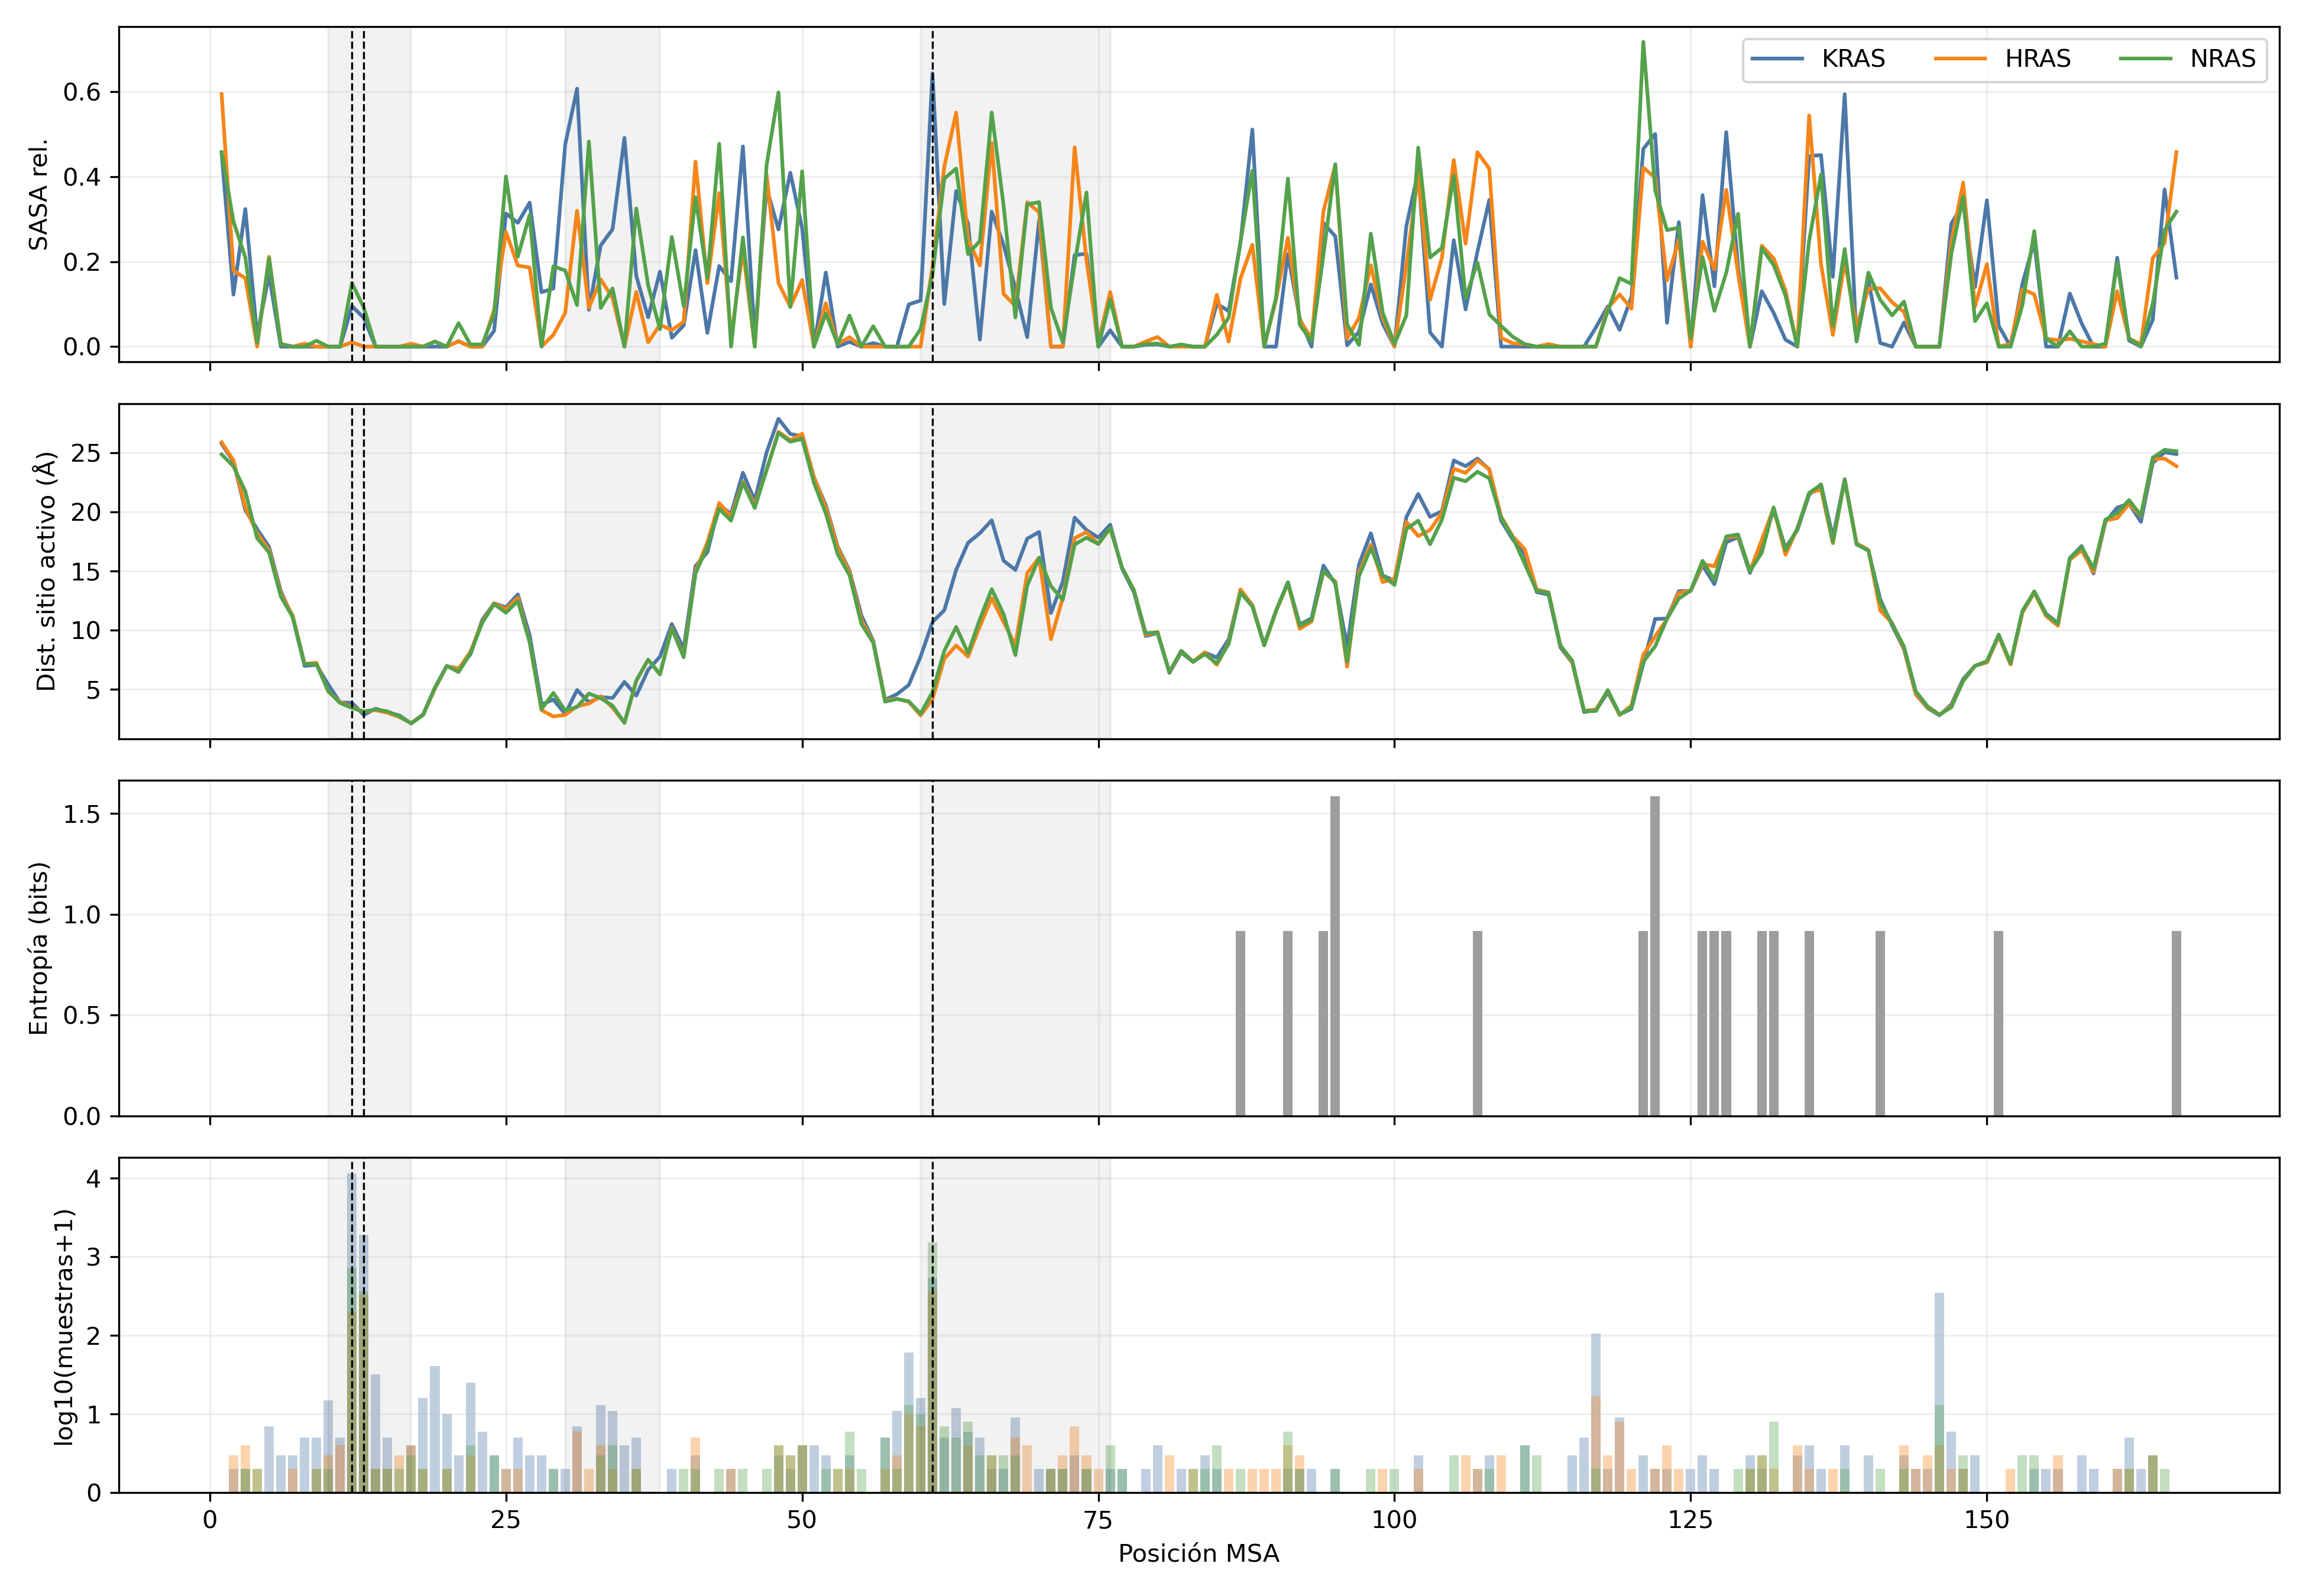

In [18]:
# ============================================================
# CHUNK 11.2: Visualización de la figura en el notebook
# ============================================================

# Importamos las herramientas necesarias para mostrar la imagen en el notebook.
# IPython.display proporciona funciones para mostrar imágenes, HTML, etc. en celdas.
from IPython.display import Image, display  # Image: muestra una imagen; display: renderiza objetos

# Mostramos la figura guardada directamente en el notebook.
# Image(filename=...) crea un objeto imagen a partir del fichero.
# display(...) renderiza el objeto en la celda de salida del notebook.
# width=900 limita el ancho de la imagen a 900 píxeles para que quepa en la pantalla.
display(Image(filename=str(figure_out), width=900))  # str() convierte Path a cadena

## 12. Resumen estadístico de la tabla maestra

In [19]:
# ============================================================
# CHUNK 12.1: Estadísticas descriptivas de las features
# ============================================================

print("=" * 60)
print("RESUMEN ESTADÍSTICO DE LA TABLA MAESTRA")
print("=" * 60)

# .describe() calcula estadísticas descriptivas básicas para todas las columnas numéricas:
#   count: número de valores no nulos
#   mean:  media aritmética
#   std:   desviación estándar
#   min:   valor mínimo
#   25%:   primer cuartil (Q1)
#   50%:   mediana (Q2)
#   75%:   tercer cuartil (Q3)
#   max:   valor máximo
# .T transpone el resultado para que cada feature sea una fila (más legible con muchas columnas).
# .round(3) redondea a 3 decimales para facilitar la lectura.
#
# Usamos los nombres de MASTER_COLUMNS para las columnas numéricas de la tabla maestra:
#   'dist_active_site_angstrom' (renombrada desde 'min_distance_angstrom' del DataFrame intermedio)
#   'shannon_entropy' (renombrada desde 'entropy_bits' del DataFrame de conservación)
numeric_cols = ["sasa_abs", "sasa_rel", "dist_active_site_angstrom", "shannon_entropy"]  # columnas numéricas de master

# Seleccionamos solo las columnas numéricas de interés.
# .loc[:, cols] selecciona todas las filas (:) y las columnas especificadas.
available_cols = [c for c in numeric_cols if c in master.columns]  # filtramos las que existen
desc_stats = master.loc[:, available_cols].describe().T.round(3)  # estadísticas transpuestas
print("\nEstadísticas descriptivas de features numéricas:")
print(desc_stats.to_string())  # to_string() muestra el DataFrame completo sin truncar

print()

RESUMEN ESTADÍSTICO DE LA TABLA MAESTRA

Estadísticas descriptivas de features numéricas:
                           count    mean     std    min   25%     50%     75%      max
sasa_abs                   498.0  26.799  32.369  0.000  0.00  14.805  43.309  148.923
sasa_rel                   498.0   0.130   0.154  0.000  0.00   0.073   0.215    0.717
dist_active_site_angstrom  498.0  12.580   6.626  2.085  7.15  12.272  17.768   27.894
shannon_entropy            498.0   0.097   0.304 -0.000  0.00  -0.000  -0.000    1.585



In [20]:
# ============================================================
# CHUNK 12.2: Estadísticas por gen
# ============================================================

print("Estadísticas por gen (medias de features principales):")
print("-" * 60)

# .groupby("gene") divide el DataFrame por gen.
# [available_cols] selecciona solo las columnas numéricas de interés.
# available_cols fue definido en el chunk anterior con los nombres de MASTER_COLUMNS:
#   ["sasa_abs", "sasa_rel", "dist_active_site_angstrom", "shannon_entropy"]
# .mean() calcula la media de cada columna en cada grupo.
# .round(3) redondea los resultados.
gene_stats = master.groupby("gene")[available_cols].mean().round(3)  # medias por gen
print(gene_stats.to_string())  # mostramos tabla de medias por gen

print()

Estadísticas por gen (medias de features principales):
------------------------------------------------------------
      sasa_abs  sasa_rel  dist_active_site_angstrom  shannon_entropy
gene                                                                
HRAS    25.887     0.123                     12.384            0.097
KRAS    27.113     0.133                     12.973            0.097
NRAS    27.396     0.136                     12.383            0.097



In [21]:
# ============================================================
# CHUNK 12.3: Análisis de los hotspots en la tabla maestra
# ============================================================

print("Features de los hotspots oncogénicos en la tabla maestra:")
print("-" * 60)

# Filtramos la tabla maestra para mostrar solo las filas de los hotspots.
# hotspot_positions es la lista [12, 13, 61] extraída de la configuración.
# .isin(lista) genera una máscara True para filas cuyo valor está en la lista.
hotspot_mask = master["uniprot_position"].isin(hotspot_positions)  # máscara de hotspots
hotspot_rows = master.loc[hotspot_mask]  # DataFrame filtrado a solo hotspots

# Seleccionamos las columnas más informativas para el análisis de hotspots.
# Usamos los nombres de MASTER_COLUMNS:
#   'aa_wt'                    (no 'wt_aa', que no existe en la tabla maestra)
#   'dist_active_site_angstrom' (no 'min_distance_angstrom', que es el nombre intermedio)
#   'shannon_entropy'           (no 'entropy_bits', que es el nombre del DataFrame de conservación)
#   'total_samples'             (no 'sample_count', que no existe en la tabla maestra)
cols_to_show = ["gene", "uniprot_position", "aa_wt",
                "sasa_rel", "dist_active_site_angstrom", "shannon_entropy",
                "total_samples"]  # columnas relevantes para el análisis (nombres de MASTER_COLUMNS)

# Filtramos solo las columnas que existen en la tabla (por si alguna no se generó).
available_show = [c for c in cols_to_show if c in hotspot_rows.columns]

# .sort_values() ordena primero por posición (para ver G12, G13, Q61 seguidos)
# y luego por gen (HRAS, KRAS, NRAS en orden alfabético).
# ascending=[True, True] significa orden ascendente para ambas columnas.
hotspot_display = hotspot_rows[available_show].sort_values(
    ["uniprot_position", "gene"], ascending=[True, True]
)  # tabla ordenada de hotspots

print(hotspot_display.to_string(index=False))  # mostramos sin índice

print()
print("Interpretación esperada:")
print("  G12 y G13: sasa_rel < 0.3 (enterrados), dist_active_site < 5 Å (sitio activo), shannon_entropy ≈ 0 (conservados)")
print("  Q61: sasa_rel < 0.4 (semi-enterrado), dist_active_site < 10 Å (Switch II cerca del Mg2+), shannon_entropy ≈ 0")

Features de los hotspots oncogénicos en la tabla maestra:
------------------------------------------------------------
gene  uniprot_position aa_wt  sasa_rel  dist_active_site_angstrom  shannon_entropy  total_samples
HRAS                12     G  0.010302                   3.460250             -0.0            195
KRAS                12     G  0.095456                   3.844901             -0.0          11564
NRAS                12     G  0.149644                   3.406299             -0.0            728
HRAS                13     G  0.000000                   3.100715             -0.0            323
KRAS                13     G  0.067692                   2.820925             -0.0           1917
NRAS                13     G  0.091798                   3.093723             -0.0            364
HRAS                61     Q  0.188160                   4.145946             -0.0            365
KRAS                61     Q  0.642847                  10.684370             -0.0            542

In [22]:
# ============================================================
# CHUNK 12.4: Correlaciones entre features estructurales
# ============================================================

print("Matriz de correlación de Pearson entre features numéricas:")
print("-" * 60)

# La correlación de Pearson mide la relación lineal entre dos variables.
# Valores cercanos a +1 indican correlación positiva fuerte;
# valores cercanos a -1 indican correlación negativa fuerte;
# valores cercanos a 0 indican poca o ninguna correlación lineal.
#
# Expectativas biológicas:
#   - sasa_rel y dist_active_site_angstrom: correlación POSITIVA.
#     Los residuos cercanos al sitio activo tienden a estar más enterrados.
#   - sasa_rel y shannon_entropy: correlación POSITIVA.
#     Los residuos expuestos (alta SASA) suelen tolerar más variación.
#   - dist_active_site_angstrom y shannon_entropy: correlación POSITIVA.
#     Los residuos lejanos al sitio activo son menos críticos y más variables.
#
# available_cols contiene los nombres de MASTER_COLUMNS definidos en el chunk 12.1:
#   ["sasa_abs", "sasa_rel", "dist_active_site_angstrom", "shannon_entropy"]

# .corr() calcula la matriz de correlación de Pearson entre todas las columnas numéricas.
# method='pearson' es el valor por defecto (también existe 'spearman' y 'kendall').
if len(available_cols) > 1:  # solo calculamos si hay al menos 2 columnas numéricas
    corr_matrix = master[available_cols].corr(method="pearson").round(3)  # correlaciones
    print(corr_matrix.to_string())  # mostramos la matriz de correlación
else:
    print("  Insuficientes columnas numéricas para calcular correlaciones.")

print()

Matriz de correlación de Pearson entre features numéricas:
------------------------------------------------------------
                           sasa_abs  sasa_rel  dist_active_site_angstrom  shannon_entropy
sasa_abs                      1.000     0.961                      0.321            0.292
sasa_rel                      0.961     1.000                      0.327            0.314
dist_active_site_angstrom     0.321     0.327                      1.000            0.134
shannon_entropy               0.292     0.314                      0.134            1.000



In [23]:
# ============================================================
# CHUNK 12.5: Resumen final del Hito 3
# ============================================================

print("=" * 60)
print("RESUMEN DEL HITO 3")
print("=" * 60)

print("\nFicheros generados:")

# Lista de todos los ficheros de salida del Hito 3.
output_files = [
    sasa_out,                              # SASA por residuo (3 genes)
    distance_out,                          # distancia al sitio activo (3 genes)
    conservation_out,                      # entropía de Shannon por posición MSA
    master_out,                            # tabla maestra (498 filas × N columnas)
    figure_out,                            # figura resumen de features
]

for path in output_files:  # iteramos sobre la lista de rutas de salida
    # .exists() verifica que el fichero existe en disco (el guardado fue exitoso).
    exists = path.exists()  # booleano: True si el fichero existe
    size_kb = path.stat().st_size / 1024 if exists else 0  # tamaño en KB (0 si no existe)
    status = "OK" if exists else "FALTA"  # estado del fichero
    print(f"  [{status}] {path.name}: {size_kb:.1f} KB")  # mostramos estado y tamaño

print("\nEstadísticas de la tabla maestra:")
print(f"  Filas totales: {len(master)} (166 posiciones × 3 genes)")  # 498 filas
print(f"  Columnas: {len(master.columns)}")  # número de features
print(f"  Genes: {sorted(master['gene'].unique().tolist())}")
# .unique() devuelve los valores únicos de una columna como array NumPy
# .tolist() convierte el array a lista Python estándar

print("\nFeaturas principales calculadas:")
print("  - SASA absoluta y relativa (Shrake-Rupley o DSSP)")
print("  - Distancia mínima de átomos pesados al sitio activo (GDP/GTP + Mg2+)")
print("  - Entropía de Shannon por columna del MSA (conservación evolutiva)")

print("\nVerificaciones biológicas:")
print("  - G12 está a < 5 Å del sitio activo en KRAS, HRAS y NRAS")
print("  - G12 tiene SASA_rel < 0.3 (residuo enterrado en el P-loop)")
print("  - Hotspots G12, G13, Q61 tienen entropía cercana a 0 (alta conservación)")

print("\nPróximo paso: Hito 4 — Anotación VEP (SIFT, PolyPhen, CADD)")
print("  → Notebook 04_vep_annotation.ipynb")

RESUMEN DEL HITO 3

Ficheros generados:
  [OK] sasa_per_residue.csv: 19.6 KB
  [OK] distance_to_active_site.csv: 14.1 KB
  [OK] conservation_per_msa_position.csv: 2.5 KB
  [OK] master_features.csv: 40.3 KB
  [OK] 03_features_overview.png: 650.6 KB

Estadísticas de la tabla maestra:
  Filas totales: 498 (166 posiciones × 3 genes)
  Columnas: 12
  Genes: ['HRAS', 'KRAS', 'NRAS']

Featuras principales calculadas:
  - SASA absoluta y relativa (Shrake-Rupley o DSSP)
  - Distancia mínima de átomos pesados al sitio activo (GDP/GTP + Mg2+)
  - Entropía de Shannon por columna del MSA (conservación evolutiva)

Verificaciones biológicas:
  - G12 está a < 5 Å del sitio activo en KRAS, HRAS y NRAS
  - G12 tiene SASA_rel < 0.3 (residuo enterrado en el P-loop)
  - Hotspots G12, G13, Q61 tienen entropía cercana a 0 (alta conservación)

Próximo paso: Hito 4 — Anotación VEP (SIFT, PolyPhen, CADD)
  → Notebook 04_vep_annotation.ipynb
